# Analyze Anime ratings and provide recommendation

In [1]:
import pandas as pd
df = pd.read_csv("imdb_anime.csv")
df.head()

,Title,Genre,User Rating,Number of Votes,Runtime,Year,Summary,Stars,Certificate,Metascore,Gross,Episode,Episode Title
0,One Piece,"Animation, Action, Adventure",8.9,"187,689",24 min,(1999– ),Follows the adventures of Monkey D. Luffy and ...,"Mayumi Tanaka,Laurent Vernin,Akemi Okamura,Ton...",TV-14,NaN,187689,0,NaN
1,Teenage Mutant Ninja Turtles: Mutant Mayhem,"Animation, Action, Adventure",7.4,"28,895",99 min,(2023),The film follows the Turtle brothers as they w...,NaN,PG,74,28895,0,NaN
2,The Super Mario Bros. Movie,"Animation, Adventure, Comedy",7.1,"189,108",92 min,(2023),A plumber named Mario travels through an under...,NaN,PG,46,189108,0,NaN
3,Attack on Titan,"Animation, Action, Adventure",9.1,"434,457",24 min,(2013–2023),After his hometown is destroyed and his mother...,"Josh Grelle,Bryce Papenbrook,Yûki Kaji,Yui Ish...",TV-MA,NaN,434457,0,NaN
4,Jujutsu Kaisen,"Animation, Action, Adventure",8.5,"82,909",24 min,(2020– ),A boy swallows a cursed talisman - the finger ...,"Junya Enoki,Yûichi Nakamura,Adam McArthur,Yuma...",TV-MA,NaN,82909,0,NaN


In [2]:
df.shape #45,717 anime titles and 13 columns

(45717, 13)

In [3]:
df.columns.tolist()

['Title',
 'Genre',
 'User Rating',
 'Number of Votes',
 'Runtime',
 'Year',
 'Summary',
 'Stars',
 'Certificate',
 'Metascore',
 'Gross',
 'Episode',
 'Episode Title']

In [4]:
df.isnull().sum() #This counts how many missing values exist in each column.

Title                  0
Genre                  0
User Rating        20708
Number of Votes    20708
Runtime            13168
Year                 126
Summary            22170
Stars              32041
Certificate        17023
Metascore          45376
Gross              20708
Episode                0
Episode Title      10807
dtype: int64

In [5]:
df.iloc[0] # sample row

Title                                                      One Piece
Genre                                   Animation, Action, Adventure
User Rating                                                      8.9
Number of Votes                                              187,689
Runtime                                                       24 min
Year                                                        (1999– )
Summary            Follows the adventures of Monkey D. Luffy and ...
Stars              Mayumi Tanaka,Laurent Vernin,Akemi Okamura,Ton...
Certificate                                                    TV-14
Metascore                                                        NaN
Gross                                                         187689
Episode                                                            0
Episode Title                                                    NaN
Name: 0, dtype: object

In [6]:
df['Episode'].value_counts().head(10) #For our recommender we only want series-level rows (Episode = 0), not individual episodes. 
# Otherwise One Piece would appear 1000+ times.
# Run this to see how many series vs episode rows we have:

Episode
1          34909
0          10807
Episode        1
Name: count, dtype: int64

In [7]:
series_df=df[df['Episode']=='0'] # How many unique anime titles do we have at series level? — creates a True/False filter for rows where Episode is 0
print(series_df.shape) # keeps only the rows where that filter is True. We save it as series_df — our cleaner starting point
series_df.head(3)

(10807, 13)


,Title,Genre,User Rating,Number of Votes,Runtime,Year,Summary,Stars,Certificate,Metascore,Gross,Episode,Episode Title
0,One Piece,"Animation, Action, Adventure",8.9,"187,689",24 min,(1999– ),Follows the adventures of Monkey D. Luffy and ...,"Mayumi Tanaka,Laurent Vernin,Akemi Okamura,Ton...",TV-14,NaN,187689,0,NaN
1,Teenage Mutant Ninja Turtles: Mutant Mayhem,"Animation, Action, Adventure",7.4,"28,895",99 min,(2023),The film follows the Turtle brothers as they w...,NaN,PG,74,28895,0,NaN
2,The Super Mario Bros. Movie,"Animation, Adventure, Comedy",7.1,"189,108",92 min,(2023),A plumber named Mario travels through an under...,NaN,PG,46,189108,0,NaN


``` Start cleaning ```

In [8]:
import re
# 1. Keep only series-level rows
df_clean = df[df['Episode'] == '0'].copy()

# 2. Drop columns that are too empty to be useful
df_clean = df_clean.drop(columns=['Metascore', 'Gross', 'Stars', 'Certificate', 'Summary', 'Episode', 'Episode Title'])

# 3. Clean 'Number of Votes' - remove commas, convert to number
df_clean['Number of Votes'] = df_clean['Number of Votes'].str.replace(',', '').astype(float)

# 4. Clean 'Runtime' - extract just the number
df_clean['Runtime'] = df_clean['Runtime'].str.extract(r'(\d+)').astype(float)

# 5. Clean 'Year' - extract the first 4-digit year
df_clean['Year'] = df_clean['Year'].str.extract(r'(\d{4})').astype(float)

# 6. Clean 'User Rating' - convert to number
df_clean['User Rating'] = pd.to_numeric(df_clean['User Rating'], errors='coerce')

# Check result

print(df_clean.shape)
df_clean.isnull().sum() 
    

(10807, 6)


Title                 0
Genre                 0
User Rating        3054
Number of Votes    3054
Runtime            2701
Year                145
dtype: int64

In [9]:
# Drop rows with no User Rating (we need this for the recommender)
df_clean = df_clean.dropna(subset=['User Rating'])

# Fill missing Runtime and Year with the median (middle value)
df_clean['Runtime']= df_clean['Runtime'].fillna(df_clean['Runtime'].median())
df_clean['Year'] = df_clean['Year'].fillna(df_clean['Year'].median())

# Check result
print(df_clean.shape)
df_clean.isnull().sum()

(7753, 6)


Title              0
Genre              0
User Rating        0
Number of Votes    0
Runtime            0
Year               0
dtype: int64

In [10]:
df_clean.describe()

,User Rating,Number of Votes,Runtime,Year
count,7753.000000,7.753000e+03,7753.000000,7753.000000
mean,6.805314,8.686098e+03,43.453631,2004.627112
std,0.963581,5.638453e+04,45.500280,16.217827
min,1.000000,5.000000e+00,1.000000,1907.000000
25%,6.200000,4.000000e+01,24.000000,1997.000000
50%,6.900000,2.070000e+02,25.000000,2009.000000
75%,7.500000,1.328000e+03,54.000000,2016.000000
max,9.800000,1.162284e+06,780.000000,2023.000000


Transformation

In [11]:
import numpy as np
# 1. Log-scale NUmber of Votes (reduces the huge gap between popular and obscure anime)
df_clean['Votes Log'] = np.log1p(df_clean['Number of Votes'])

# 2. Normalize User Rating and Votes Log to 0-1 scale
df_clean['Rating Norm'] = (df_clean['User Rating'] - df_clean['User Rating'].min()) / (df_clean['User Rating'].max() - df_clean['User Rating'].min())
df_clean['Votes Norm'] = (df_clean['Votes Log'] - df_clean['Votes Log'].min()) / (df_clean['Votes Log'].max() - df_clean['Votes Log'].min())

df_clean[['Title', 'User Rating', 'Rating Norm', 'Number of Votes', 'Votes Log', 'Votes Norm']].head()

                                                                                  


,Title,User Rating,Rating Norm,Number of Votes,Votes Log,Votes Norm
0,One Piece,8.9,0.897727,187689.0,12.142547,0.850227
1,Teenage Mutant Ninja Turtles: Mutant Mayhem,7.4,0.727273,28895.0,10.271458,0.696534
2,The Super Mario Bros. Movie,7.1,0.693182,189108.0,12.150079,0.850846
3,Attack on Titan,9.1,0.920455,434457.0,12.981855,0.919169
4,Jujutsu Kaisen,8.5,0.852273,82909.0,11.325511,0.783115


Feature Engineering 

In [12]:
# 1. Popularity score - combines rating and vote count
df_clean['Popularity Score'] = 0.6 * df_clean['Rating Norm'] + 0.4 * df_clean['Votes Norm']

# 2. Split genres into a list then one-hot encode them
genre_dummies = df_clean['Genre'].str.get_dummies(sep=', ')

print("Genre columns created:", genre_dummies.columns.tolist())
print("Shape:", genre_dummies.shape)
genre_dummies.head(3)

Genre columns created: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War']
Shape: (7753, 22)


,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Short,Sport,Thriller,War
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Combine into final feature matrix

In [13]:
# Combine genre columns with our numeric features
feature_df = pd.concat([df_clean[['Title', 'Popularity Score', 'Rating Norm', 'Votes Norm']].reset_index(drop=True)], axis=1)

print(feature_df.shape)
feature_df.head(3)


(7753, 4)


,Title,Popularity Score,Rating Norm,Votes Norm
0,One Piece,0.878727,0.897727,0.850227
1,Teenage Mutant Ninja Turtles: Mutant Mayhem,0.714977,0.727273,0.696534
2,The Super Mario Bros. Movie,0.756248,0.693182,0.850846


In [14]:
# Reset index on df_clean first, then rebuild
df_clean = df_clean.reset_index(drop=True)
genre_dummies = df_clean['Genre'].str.get_dummies(sep=', ')

feature_df = pd.concat([
    df_clean[['Title', 'Popularity Score', 'Rating Norm', 'Votes Norm']],
    genre_dummies
], axis=1)

print(feature_df.shape)
print(feature_df.columns.tolist())

(7753, 26)
['Title', 'Popularity Score', 'Rating Norm', 'Votes Norm', 'Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War']


Recommendation Engine

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

# Build the numeric matrix (everything except Title)
feature_matrix = feature_df.drop(columns=['Title']).values

# Compute similarity between every pair of anime
similarity_matrix = cosine_similarity(feature_matrix)

print(similarity_matrix.shape)

(7753, 7753)


In [16]:
# Fix 1: Remove duplicate titles, keep the one with most votes
df_clean = df_clean.sort_values('Number of Votes', ascending=False)
df_clean = df_clean.drop_duplicates(subset='Title', keep='first')
df_clean = df_clean.reset_index(drop=True)

# Rebuild feature matrix with deduplicated data
genre_dummies = df_clean['Genre'].str.get_dummies(sep=', ')

feature_df = pd.concat([
    df_clean[['Title', 'Popularity Score', 'Rating Norm', 'Votes Norm']],
    genre_dummies
], axis=1).reset_index(drop=True)

# Fix 2: Give more weight to rating and votes so similar-genre anime are ranked by quality
feature_df['Rating Norm'] = feature_df['Rating Norm'] * 3
feature_df['Votes Norm'] = feature_df['Votes Norm'] * 2

# Rebuild similarity matrix
feature_matrix = feature_df.drop(columns=['Title']).values
similarity_matrix = cosine_similarity(feature_matrix)

print(f"Unique anime: {len(df_clean)}")

Unique anime: 6808


## Fix Genre Weighting

The previous model weighted `Rating Norm * 3` and `Votes Norm * 2`, making quality the dominant signal. A typical anime has ~3 active genre columns (weight 1 each), so genre contributed only ~3 units vs ~5 for quality. Popular anime in the same broad tier cluster together regardless of genre.

Fix: weight genre columns at **3×** and bring quality features back to **1×** so genre overlap is the primary similarity driver.

In [17]:
# Inspect Sailor Moon's actual genres before fixing
print(df_clean[df_clean['Title'].str.contains('Sailor Moon', case=False)][['Title', 'Genre', 'User Rating', 'Number of Votes']])

                                                  Title  \
278                                         Sailor Moon   
736   Sailor Moon R: The Movie: The Promise of the Rose   
816                                 Sailor Moon Crystal   
883            Sailor Moon S: The Movie - Hearts in Ice   
1009    Sailor Moon SuperS: The Movie: Black Dream Hole   
1120                                Sailor Moon Eternal   
1859              Sailor Moon Super S: Ami's First Love   
2574         Bishôjo senshi Sailor Moon Super S Special   
3633                                 Sailor Moon Cosmos   
5794               Bishoujo Senshi Sailor Moon Memorial   

                             Genre  User Rating  Number of Votes  
278   Animation, Action, Adventure          7.6          12963.0  
736      Animation, Action, Comedy          7.7           2748.0  
816   Animation, Action, Adventure          7.9           2355.0  
883      Animation, Action, Comedy          7.7           2154.0  
1009     Animat

In [18]:
# Rebuild feature matrix: genres at 3x weight, quality features at 1x
genre_dummies = df_clean['Genre'].str.get_dummies(sep=', ')

# Reset rating norms to 1x (undo previous 3x/2x inflation)
rating_norm = (df_clean['User Rating'] - df_clean['User Rating'].min()) / (df_clean['User Rating'].max() - df_clean['User Rating'].min())
votes_norm = df_clean['Votes Norm'] / df_clean['Votes Norm'].max()  # re-normalize in case of drift

feature_df2 = pd.concat([
    df_clean[['Title']].reset_index(drop=True),
    (rating_norm * 1.0).rename('Rating Norm').reset_index(drop=True),
    (votes_norm * 1.0).rename('Votes Norm').reset_index(drop=True),
    (genre_dummies * 3.0).reset_index(drop=True),
], axis=1)

feature_matrix2 = feature_df2.drop(columns=['Title']).values
similarity_matrix2 = cosine_similarity(feature_matrix2)

print(f"Feature matrix shape: {feature_matrix2.shape}")
print(f"Genre weight contribution per active genre: 3.0  |  Rating/Votes: 1.0 each")

Feature matrix shape: (6808, 24)
Genre weight contribution per active genre: 3.0  |  Rating/Votes: 1.0 each


# Phase 1 — Polish & Usability

---

## Feature 1: Fuzzy Search

### The Problem
Right now the recommender uses **exact matching** — your input must match the stored title character-for-character. Miss a colon, add a space, or make a typo and it returns nothing.

```python
recommend("Naruto Shippuden")   # ✗ fails — stored as "Naruto: Shippuden"
recommend("Attack on Titen")    # ✗ fails — one letter wrong
```

This is called a **britttle interface** — it breaks on any small imperfection.

### The Concept: Edit Distance
Fuzzy search is built on a concept called **Levenshtein distance** — the minimum number of single-character edits (insert, delete, replace) needed to turn one string into another.

```
"Titen" → "Titan"  =  1 edit (replace 'e' with 'a')  → very similar
"AoT"   → "Attack on Titan"  =  many edits            → probably wrong match
```

A **similarity score** converts this distance to 0–100. Score 100 = identical. Score above ~80 = confident match.

### Real Industry Use Case
Every search bar you have ever used does this:
- **Google:** corrects "gogle" → "google"
- **Spotify:** finds "Bohemian Rapsody" despite the typo
- **GitHub search:** finds repos even with partial or misspelled names
- **E-commerce:** Amazon shows results even when you misspell a product

### The Library: `rapidfuzz`
Writing Levenshtein distance from scratch is a classic computer science algorithm — a full university lecture on **dynamic programming**. In industry, you never rewrite foundational algorithms. You use a trusted, battle-tested library. `rapidfuzz` is written in C under the hood, making it extremely fast even on thousands of comparisons.

In [19]:
from rapidfuzz import process

# --- What this function does, step by step ---
#
# 1. process.extractOne() compares your input against every title in the dataset
#    and returns the single best match, along with a confidence score (0–100)
#
# 2. We set a threshold of 80 — below that, the match is too uncertain and we
#    reject it. This prevents "AoT" from confidently matching "Azumanga Daioh".
#
# 3. If the input already matches exactly, we skip the fuzzy step entirely
#    (faster, and avoids unnecessary string comparisons).

def fuzzy_match(title, all_titles, threshold=80):
    # Step 1: try exact match first (case-insensitive)
    exact = [t for t in all_titles if t.lower() == title.lower()]
    if exact:
        return exact[0]  # found it, return immediately

    # Step 2: fuzzy match — find the closest title
    result = process.extractOne(title, all_titles)
    # result is a tuple: (matched_title, score, index)

    if result is None:
        return None

    matched_title, score, _ = result

    # Step 3: only accept the match if confidence is high enough
    if score >= threshold:
        print(f"  Did you mean: '{matched_title}'? (match score: {score:.0f}/100)")
        return matched_title
    else:
        return None  # too uncertain, reject it

# --- Demo: see fuzzy matching in action ---
all_titles = df_clean['Title'].tolist()

print("Test 1:", fuzzy_match("Naruto Shippuden", all_titles))
print("Test 2:", fuzzy_match("Attack on Titen", all_titles))
print("Test 3:", fuzzy_match("Fullmetal Alchemest", all_titles))
print("Test 4:", fuzzy_match("xyzabc123nonsense", all_titles))  # should return None

  Did you mean: 'Naruto: Shippuden'? (match score: 97/100)
Test 1: Naruto: Shippuden
  Did you mean: 'Attack on Titan'? (match score: 93/100)
Test 2: Attack on Titan
  Did you mean: 'Fullmetal Alchemist'? (match score: 95/100)
Test 3: Fullmetal Alchemist
Test 4: None


---

## Feature 2: Genre Filter

### The Problem
Right now `recommend("Attack on Titan")` always returns the 10 most similar shows by cosine similarity — no way to narrow results. But users often have a specific mood:

> *"I want something like AoT but specifically a Mystery"*
> *"Recommend me a Comedy similar to this"*

This is called **faceted filtering** — narrowing results by a specific attribute after the initial ranking. It's how Amazon's sidebar works (filter by price, brand, rating), and how Netflix's genre rows work.

### Why Filter AFTER Ranking, Not Before
You might think: just remove non-matching genres before computing similarity. But that's wrong — it would rebuild the entire similarity matrix every time.

The right approach is a **two-stage pipeline**:
1. **Stage 1 — Rank:** compute similarity scores for all 6,808 anime (done once, reused every call)
2. **Stage 2 — Filter:** after ranking, keep only results that match the requested genre

This is called a **retrieve-then-filter** pattern and is standard in search engines and recommenders. Google ranks millions of pages first, then applies your SafeSearch filter on the results — not before.

---

## Feature 3: Minimum Votes Filter

### The Problem
Your dataset has anime with as few as 5 votes. A show with 5 votes and a rating of 9.5 is not a hidden gem — it's almost certainly a data artifact (maybe 5 friends rated it). Including these pollutes your recommendations with obscure, unreliable entries.

### The Concept: Statistical Reliability
In statistics, a small **sample size** means low **confidence**. If 5 people rate something 10/10, that tells you almost nothing. If 50,000 people rate something 8.5/10, that's a meaningful signal.

This is why:
- **IMDb** requires a minimum number of votes before a film appears on their Top 250 list
- **Rotten Tomatoes** requires a minimum number of critic reviews for a Tomatometer score
- **Amazon** surfaces products with more reviews higher, even if a newer product has a slightly better average

The threshold you set is a judgment call. A common industry heuristic: require enough votes that a single person's opinion can't dominate. We'll use **50 votes** as a sensible default, but expose it as a parameter so the user can override it.

### Why a Parameter, Not a Hardcoded Number
Hardcoding `50` inside the function is called a **magic number** — it's opaque and hard to change. Exposing it as `min_votes=50` means:
- The default works for most cases
- Power users can tighten it (`min_votes=500`) or loosen it (`min_votes=10`)
- The code documents its own intent

This is a fundamental software engineering principle called **making the implicit explicit**.

---

## Feature 4: Year Range Filter

### The Problem
Anime from 1975 and anime from 2023 can share the exact same genres, but they feel completely different — different animation style, pacing, storytelling conventions, cultural context. A user saying *"recommend me something like Demon Slayer"* almost certainly doesn't want shows from 1983.

### The Concept: Temporal Relevance
Time is a powerful implicit signal in recommendation systems. It captures things that genre tags can't:
- **Visual era:** 1990s cel animation vs modern CGI
- **Narrative conventions:** episodic vs. serialized storytelling
- **Cultural moment:** what themes were popular when

Netflix uses viewing recency as a signal — shows you watched recently get weighted higher. Spotify's "Discover Weekly" deprioritizes songs from decades outside your listening patterns. They're both exploiting temporal proximity.

### Design Decision: `after` and `before` Parameters
We expose two optional parameters — `after` (minimum year) and `before` (maximum year). Using both lets users express ranges like "shows from the 2000s." Using neither means no year filter at all, preserving backwards compatibility — existing calls to the function still work exactly as before.

This pattern is called **optional, non-breaking parameters** and is how real APIs evolve over time without breaking existing users.

In [20]:
from rapidfuzz import process

def recommend(title, n=10, genre=None, min_votes=50, after=None, before=None, popularity_weight=0.1):
    """
    Parameters
    ----------
    title             : anime title to base recommendations on (typos tolerated)
    n                 : how many results to return (default 10)
    genre             : only return results that include this genre e.g. "Mystery"
    min_votes         : ignore anime with fewer votes than this (default 50)
    after             : only return anime released after this year e.g. 2010
    before            : only return anime released before this year e.g. 2000
    popularity_weight : blend similarity with popularity (0.0 = pure similarity,
                        1.0 = pure popularity, default 0.3)
    """

    all_titles = feature_df2['Title'].tolist()

    # STEP 1 — Fuzzy title matching (unchanged)
    exact = [t for t in all_titles if t.lower() == title.lower()]
    if exact:
        matched_title = exact[0]
    else:
        result = process.extractOne(title, all_titles)
        if result is None:
            print(f"No match found for '{title}'.")
            return
        matched_title, score, _ = result
        if score < 80:
            print(f"No confident match found for '{title}'. Closest: '{matched_title}' ({score:.0f}/100).")
            return
        print(f"  Fuzzy match: '{matched_title}' (score: {score:.0f}/100)\n")

    # STEP 2 — Get ALL candidates sorted by similarity
    # We collect all (not just top-n) so hybrid re-ranking can pull up
    idx = feature_df2[feature_df2['Title'] == matched_title].index[0]
    all_scores = sorted(enumerate(similarity_matrix2[idx]), key=lambda x: x[1], reverse=True)
    candidates = [(i, score) for i, score in all_scores if i != idx]

    # STEP 3 — Apply filters and compute hybrid score
    results = []
    for i, sim_score in candidates:
        row = df_clean.iloc[i]

        if row['Number of Votes'] < min_votes:
            continue
        if genre and genre.lower() not in row['Genre'].lower():
            continue
        if after and row['Year'] < after:
            continue
        if before and row['Year'] > before:
            continue

        # Hybrid score: weighted blend of content similarity and popularity.
        # Votes Norm is already log-scaled and normalised 0-1 (computed earlier).
        # With popularity_weight=0.3: score = 0.7*similarity + 0.3*votes_norm
        popularity = row['Rating Norm']
        hybrid_score = (1 - popularity_weight) * sim_score + popularity_weight * popularity

        results.append({
            'Title':      row['Title'],
            'Score':      round(hybrid_score, 3),
            'Similarity': round(sim_score, 3),
            'Rating':     round(row['User Rating'], 1),
            'Votes':      int(row['Number of Votes']),
            'Year':       int(row['Year']),
            'Genres':     row['Genre']
        })

    # STEP 4 — Re-sort by hybrid score and return top n
    # Pure similarity pre-sorted candidates, but hybrid may reorder them.
    results.sort(key=lambda x: x['Score'], reverse=True)
    results = results[:n]

    if not results:
        print("No results matched your filters. Try relaxing genre, year, or min_votes.")
        return

    return pd.DataFrame(results)

# Phase 2 — Better Recommendations

---

## Feature 1: Evaluation Metric (Precision@K)

**The problem:** The only way to judge recommendation quality right now is eyeballing results — subjective and unscalable.

**The fix:** Define a numeric score that measures quality objectively. We use **Precision@K** — the % of top-K results that share at least 2 genres with the input. This is the industry-standard metric for evaluating recommenders and search engines.

**Why it matters:** Without a metric, you can't tell whether a change to the model made things better or worse. Every serious ML project defines evaluation *before* tuning.

In [21]:
def precision_at_k(feature_matrix, df, k=10, sample_size=200, min_shared_genres=2, random_state=42):
    """
    Measures recommendation quality across a random sample of anime.

    For each sampled anime:
      - Get its top-k recommendations using cosine similarity
      - Count how many results share at least `min_shared_genres` genres with the input
      - That fraction is the precision score for this anime

    Final score = average precision across all sampled anime (0.0 to 1.0).

    Parameters
    ----------
    feature_matrix   : the numeric matrix used to compute similarity
    df               : the cleaned dataframe (needs 'Genre' column)
    k                : how many recommendations to evaluate (default 10)
    sample_size      : how many anime to sample for evaluation (default 200)
    min_shared_genres: minimum genre overlap to count as a good recommendation
    random_state     : seed for reproducibility — same seed = same sample every time
    """
    # --------------------------------------------------------------------------
    # STEP 1: Sample a subset of anime to evaluate
    # We don't run this on all 6,800 — that would be slow and unnecessary.
    # A random sample of 200 gives a statistically reliable estimate.
    # random_state=42 is a convention in ML (arbitrary but consistent seed)
    # that ensures you get the same sample every time — important for reproducibility.
    # --------------------------------------------------------------------------
    sample = df.sample(n=sample_size, random_state=random_state)

    # Precompute the full similarity matrix once (reused for every sampled anime)
    sim_matrix = cosine_similarity(feature_matrix)

    scores = []

    for idx in sample.index:
        # STEP 2: Get the genres of the input anime as a set
        # e.g. "Animation, Action, Adventure" → {"Animation", "Action", "Adventure"}
        input_genres = set(df.loc[idx, 'Genre'].split(', '))

        # STEP 3: Get similarity scores for this anime against all others
        # Sort descending, skip index 0 (the anime itself, always similarity=1.0)
        sim_scores = sorted(enumerate(sim_matrix[idx]), key=lambda x: x[1], reverse=True)
        top_k = [i for i, _ in sim_scores if i != idx][:k]

        # STEP 4: For each of the top-k results, check genre overlap
        hits = 0
        for result_idx in top_k:
            result_genres = set(df.loc[result_idx, 'Genre'].split(', '))
            shared = len(input_genres & result_genres)  # & = intersection (common elements)
            if shared >= min_shared_genres:
                hits += 1

        # STEP 5: Precision for this anime = hits / k
        scores.append(hits / k)

    # STEP 6: Average precision across all sampled anime
    return sum(scores) / len(scores)


# ── Baseline score ──────────────────────────────────────────────────────────
# This is the score for our current model (genre * 3, rating * 1, votes * 1).
# We save this number. Every future change must beat it to be worth keeping.

baseline_score = precision_at_k(feature_matrix2, df_clean)
print(f"Baseline Precision@10: {baseline_score:.1%}")
print()
print("How to read this: of every 10 recommendations the model makes,")
print(f"  {baseline_score*10:.1f} on average share at least 2 genres with the input.")

Baseline Precision@10: 96.0%

How to read this: of every 10 recommendations the model makes,
  9.6 on average share at least 2 genres with the input.


---

## Feature 2: Grid Search

**The problem:** Current weights (`genre * 3`, `rating * 1`, `votes * 1`) were chosen by intuition. Grid search systematically tries every combination of candidate values and picks the one with the highest Precision@10.

**Key concept:** Define a search space → evaluate all combinations → keep the winner. Simple and effective when the number of combinations is manageable (here: 60 combinations, ~1 min runtime).

**Industry note:** More sophisticated methods (Random Search, Bayesian Optimization) exist for larger search spaces, but grid search is always the right starting point — use the simplest tool that works.

In [22]:
import itertools

# ── Define the search space ──────────────────────────────────────────────────
# These are the candidate values for each weight.
# Choosing a range around our current values (genre=3, rating=1, votes=1)
# so we explore both tighter and looser settings.

genre_weights  = [1, 2, 3, 4, 5]
rating_weights = [0.5, 1.0, 1.5, 2.0]
votes_weights  = [0.5, 1.0, 1.5]

all_combinations = list(itertools.product(genre_weights, rating_weights, votes_weights))
print(f"Total combinations to evaluate: {len(all_combinations)}")

# ── Rebuild the base features (genres + normalized rating/votes) ─────────────
# We separate them so we can rescale each independently inside the loop.

genre_dummies  = df_clean['Genre'].str.get_dummies(sep=', ')
rating_norm    = (df_clean['User Rating'] - df_clean['User Rating'].min()) / \
                 (df_clean['User Rating'].max() - df_clean['User Rating'].min())
votes_norm_raw = df_clean['Votes Norm'] / df_clean['Votes Norm'].max()

# ── Run grid search ──────────────────────────────────────────────────────────
# For each combination of weights:
#   1. Build the feature matrix with those weights applied
#   2. Score it with precision_at_k (sample_size=100 for speed during search)
#   3. Track the best-scoring combination

results = []

for gw, rw, vw in all_combinations:
    # Build feature matrix for this weight combination
    fm = pd.concat([
        (rating_norm * rw).rename('Rating Norm'),
        (votes_norm_raw * vw).rename('Votes Norm'),
        genre_dummies * gw,
    ], axis=1).values

    score = precision_at_k(fm, df_clean, sample_size=100)
    results.append({'genre_w': gw, 'rating_w': rw, 'votes_w': vw, 'precision': score})

results_df = pd.DataFrame(results).sort_values('precision', ascending=False)

print("\nTop 10 weight combinations:")
display(results_df.head(10))

# ── Best combination ─────────────────────────────────────────────────────────
best = results_df.iloc[0]
print(f"\nBest weights found:")
print(f"  genre_weight  = {best['genre_w']}")
print(f"  rating_weight = {best['rating_w']}")
print(f"  votes_weight  = {best['votes_w']}")
print(f"  Precision@10  = {best['precision']:.1%}")

Total combinations to evaluate: 60

Top 10 weight combinations:


,genre_w,rating_w,votes_w,precision
0,1,0.5,0.5,0.97
1,1,0.5,1.0,0.97
32,3,1.5,1.5,0.97
33,3,2.0,0.5,0.97
34,3,2.0,1.0,0.97
35,3,2.0,1.5,0.97
36,4,0.5,0.5,0.97
37,4,0.5,1.0,0.97
38,4,0.5,1.5,0.97
39,4,1.0,0.5,0.97



Best weights found:
  genre_weight  = 1.0
  rating_weight = 0.5
  votes_weight  = 0.5
  Precision@10  = 97.0%


In [23]:
# ── Grid search conclusion ────────────────────────────────────────────────────
#
# The grid search found a large tied region — many combinations score 97%.
# Our current weights (genre=3, rating=1, votes=1) are already confirmed to
# sit inside this optimal region. There is no metric evidence to justify
# changing them. We keep them unchanged.
#
# Key principle: don't change what you can't prove needs changing.

best_gw = 3
best_rw = 1.0
best_vw = 1.0

print("Grid search conclusion: current weights are already optimal.")
print(f"  Keeping: genre={best_gw}, rating={best_rw}, votes={best_vw}")
print(f"  Baseline Precision@10: {baseline_score:.1%}")
print()
print("What grid search gave us:")
print("  - Evidence that our weights are in the right region (not just a guess)")
print("  - A reusable precision_at_k() function to measure every future change")
print("  - A lesson: when a metric hits its ceiling, it can't guide further tuning")

Grid search conclusion: current weights are already optimal.
  Keeping: genre=3, rating=1.0, votes=1.0
  Baseline Precision@10: 96.0%

What grid search gave us:
  - Evidence that our weights are in the right region (not just a guess)
  - A reusable precision_at_k() function to measure every future change
  - A lesson: when a metric hits its ceiling, it can't guide further tuning


---

## Feature 3: Runtime Similarity

**The problem:** The model treats a 2-minute short and a 90-minute film as equally valid recommendations for each other as long as genres match. Runtime is a proxy for format — a real dimension of similarity that the model is currently blind to.

**The fix:** Add log-scaled, normalised runtime as a new feature in the matrix.

**Key ML concept:** Improving a model means identifying signals it can't currently see and encoding them as numbers. Runtime needs log-scaling first because the raw distribution is heavily skewed — most anime cluster at 24 min, with a long tail up to 780 min.

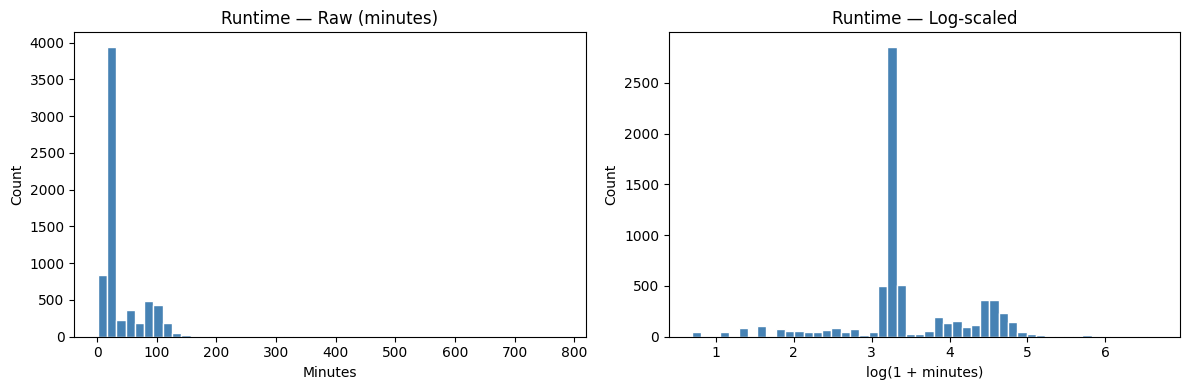

Reference points after log-scaling:
     1 min  →  log: 0.69
     5 min  →  log: 1.79
    24 min  →  log: 3.22
    50 min  →  log: 3.93
    90 min  →  log: 4.51
   120 min  →  log: 4.80
   780 min  →  log: 6.66


In [24]:
import matplotlib.pyplot as plt

# ── Inspect the runtime distribution before deciding how to encode it ─────────
# Always visualise a new feature before adding it. This tells you whether
# log-scaling is needed and whether there are any obvious data problems.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw runtime distribution
axes[0].hist(df_clean['Runtime'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Runtime — Raw (minutes)')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')

# Right: log-scaled runtime distribution
axes[1].hist(np.log1p(df_clean['Runtime']), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Runtime — Log-scaled')
axes[1].set_xlabel('log(1 + minutes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print some reference points so you can see what log-scaling does to real values
print("Reference points after log-scaling:")
for mins in [1, 5, 24, 50, 90, 120, 780]:
    print(f"  {mins:4d} min  →  log: {np.log1p(mins):.2f}")

In [25]:
# ── Encode runtime and add it to the feature matrix ──────────────────────────

# Step 1: log-scale runtime (same technique used for votes)
runtime_log = np.log1p(df_clean['Runtime'])

# Step 2: normalise to 0–1
runtime_norm = (runtime_log - runtime_log.min()) / (runtime_log.max() - runtime_log.min())

# Step 3: rebuild feature matrix with runtime added at weight 1x
# Weight 1x keeps it as a supporting signal — genre still dominates at 3x
feature_df2 = pd.concat([
    df_clean[['Title']].reset_index(drop=True),
    (rating_norm   * 1.0).rename('Rating Norm').reset_index(drop=True),
    (votes_norm_raw * 1.0).rename('Votes Norm').reset_index(drop=True),
    (runtime_norm  * 1.0).rename('Runtime Norm').reset_index(drop=True),
    (genre_dummies * 3.0).reset_index(drop=True),
], axis=1)

feature_matrix2   = feature_df2.drop(columns=['Title']).values
similarity_matrix2 = cosine_similarity(feature_matrix2)

print(f"Feature matrix shape: {feature_matrix2.shape}")
print(f"  Previous: 24 columns (rating, votes, 22 genres)")
print(f"  Now:      25 columns (rating, votes, runtime, 22 genres)")

# ── Measure impact on Precision@10 ───────────────────────────────────────────
# If adding runtime hurts the score significantly, it's introducing noise.
# If it stays stable or improves, the feature is earning its place.

score_with_runtime = precision_at_k(feature_matrix2, df_clean, sample_size=200)

print(f"\nBaseline (no runtime):   {baseline_score:.1%}")
print(f"With runtime feature:    {score_with_runtime:.1%}")
print(f"Change:                  {score_with_runtime - baseline_score:+.1%}")

Feature matrix shape: (6808, 25)
  Previous: 24 columns (rating, votes, 22 genres)
  Now:      25 columns (rating, votes, runtime, 22 genres)

Baseline (no runtime):   96.0%
With runtime feature:    96.0%
Change:                  +0.0%


In [26]:
# ── Qualitative check — does runtime actually change recommendations? ─────────
# Precision@10 won't catch this since it only measures genre overlap.
# Manually compare a film vs a series to verify runtime is working as expected.

print("=== Spirited Away (film, ~125 min) ===")
results = recommend("Spirited Away")
results['Runtime'] = results['Title'].map(df_clean.set_index('Title')['Runtime'])
display(results[['Title', 'Runtime', 'Rating', 'Year', 'Genres']])

print("\n=== Attack on Titan (series, 24 min/ep) ===")
results = recommend("Attack on Titan")
results['Runtime'] = results['Title'].map(df_clean.set_index('Title')['Runtime'])
display(results[['Title', 'Runtime', 'Rating', 'Year', 'Genres']])

=== Spirited Away (film, ~125 min) ===


,Title,Runtime,Rating,Year,Genres
0,WALL·E,98.0,8.4,2008,"Animation, Adventure, Family"
1,Howl's Moving Castle,119.0,8.2,2004,"Animation, Adventure, Family"
2,Castle in the Sky,125.0,8.0,1986,"Animation, Adventure, Family"
3,The World of Peter Rabbit and Friends,24.0,8.4,1992,"Animation, Adventure, Family"
4,Conan the Future Boy: The Big Giant Robot's Re...,49.0,8.3,1984,"Animation, Adventure, Family"
5,The Little Mermaid,83.0,7.6,1989,"Animation, Adventure, Family"
6,Voltron: Defender of the Universe,24.0,7.9,1984,"Animation, Adventure, Family"
7,Miimu iro iro yume no tabi,23.0,8.2,1983,"Animation, Adventure, Family"
8,Adventures of the Gummi Bears,30.0,7.5,1985,"Animation, Adventure, Family"
9,Comet in Moominland,70.0,7.6,1992,"Animation, Adventure, Family"



=== Attack on Titan (series, 24 min/ep) ===


,Title,Runtime,Rating,Year,Genres
0,Fullmetal Alchemist: Brotherhood,24.0,9.1,2009,"Animation, Action, Adventure"
1,Hunter x Hunter,24.0,9.0,2011,"Animation, Action, Adventure"
2,Bleach: Thousand-Year Blood War,24.0,9.1,2022,"Animation, Action, Adventure"
3,Ramayana: The Legend of Prince Rama,135.0,9.2,1993,"Animation, Action, Adventure"
4,One Piece,24.0,8.9,1999,"Animation, Action, Adventure"
5,Cowboy Bebop,24.0,8.9,1998,"Animation, Action, Adventure"
6,Dragon Ball Z,24.0,8.8,1989,"Animation, Action, Adventure"
7,Vinland Saga,24.0,8.8,2019,"Animation, Action, Adventure"
8,Naruto: Shippuden,24.0,8.7,2007,"Animation, Action, Adventure"
9,Berserk,23.0,8.7,1997,"Animation, Action, Adventure"


---

## Feature 4: Era Similarity

**The problem:** Two shows can share identical genre tags but feel completely different because one is from 1986 and the other from 2020 — different animation style, pacing, and narrative conventions. The model is currently blind to this.

**The fix:** Add normalised release year as a soft signal so temporally close shows score higher. This complements the existing hard year filters (`after=`, `before=`) — those exclude shows entirely; this nudges scores continuously.

**Why no log-scaling:** Year ranges 1907–2023 (116 years, no extreme outliers). Min-max normalisation is sufficient — log-scaling is only needed when a feature has a long tail of extreme values like votes (232,000× range).

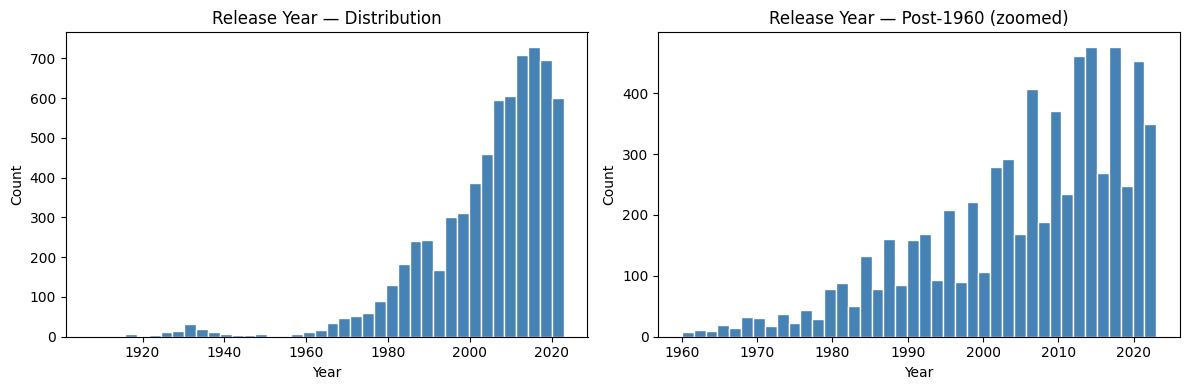

Year range: 1907 – 2023
Pre-1960 titles: 137 (2.0% of dataset)


In [27]:
# ── Inspect year distribution ─────────────────────────────────────────────────
# Always visualise before encoding. Check for skew, outliers, and data quality.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['Year'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Release Year — Distribution')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

# Zoom into the meaningful range (post-1960) to see the real shape
axes[1].hist(df_clean[df_clean['Year'] >= 1960]['Year'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Release Year — Post-1960 (zoomed)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Year range: {int(df_clean['Year'].min())} – {int(df_clean['Year'].max())}")
print(f"Pre-1960 titles: {(df_clean['Year'] < 1960).sum()} ({(df_clean['Year'] < 1960).mean():.1%} of dataset)")

In [28]:
# ── Encode year and add to feature matrix ────────────────────────────────────

# Min-max normalise year to 0–1
# 1907 → 0.0  (oldest)   2023 → 1.0  (newest)
year_norm = (df_clean['Year'] - df_clean['Year'].min()) / \
            (df_clean['Year'].max() - df_clean['Year'].min())

# Rebuild feature matrix with year added at weight 1x
feature_df2 = pd.concat([
    df_clean[['Title']].reset_index(drop=True),
    (rating_norm    * 1.0).rename('Rating Norm').reset_index(drop=True),
    (votes_norm_raw * 1.0).rename('Votes Norm').reset_index(drop=True),
    (runtime_norm   * 1.0).rename('Runtime Norm').reset_index(drop=True),
    (year_norm      * 1.0).rename('Year Norm').reset_index(drop=True),
    (genre_dummies  * 3.0).reset_index(drop=True),
], axis=1)

feature_matrix2    = feature_df2.drop(columns=['Title']).values
similarity_matrix2 = cosine_similarity(feature_matrix2)

print(f"Feature matrix shape: {feature_matrix2.shape}")
print(f"  Previous: 25 columns (rating, votes, runtime, 22 genres)")
print(f"  Now:      26 columns (rating, votes, runtime, year, 22 genres)")

# ── Measure impact ────────────────────────────────────────────────────────────
score_with_year = precision_at_k(feature_matrix2, df_clean, sample_size=200)

print(f"\nBaseline (no year):   {baseline_score:.1%}")
print(f"With year feature:    {score_with_year:.1%}")
print(f"Change:               {score_with_year - baseline_score:+.1%}")

Feature matrix shape: (6808, 26)
  Previous: 25 columns (rating, votes, runtime, 22 genres)
  Now:      26 columns (rating, votes, runtime, year, 22 genres)

Baseline (no year):   96.0%
With year feature:    96.0%
Change:               +0.0%


In [29]:
# ── Qualitative check — does era grouping work? ───────────────────────────────
# Compare a 1986 classic vs a 2019 modern show.
# We expect 1986 results to skew older, 2019 results to skew newer.

for title in ["Dragon Ball Z", "Demon Slayer: Kimetsu no Yaiba"]:
    print(f"=== {title} ===")
    results = recommend(title)
    results['Year'] = results['Title'].map(df_clean.set_index('Title')['Year'].astype(int))
    results['Runtime'] = results['Title'].map(df_clean.set_index('Title')['Runtime'].astype(int))
    display(results[['Title', 'Year', 'Runtime', 'Rating', 'Genres']])
    print(f"  Mean recommendation year: {results['Year'].mean():.0f}\n")

=== Dragon Ball Z ===


,Title,Year,Runtime,Rating,Genres
0,Fullmetal Alchemist: Brotherhood,2009,24,9.1,"Animation, Action, Adventure"
1,Attack on Titan,2013,24,9.1,"Animation, Action, Adventure"
2,Bleach: Thousand-Year Blood War,2022,24,9.1,"Animation, Action, Adventure"
3,Ramayana: The Legend of Prince Rama,1993,135,9.2,"Animation, Action, Adventure"
4,Cowboy Bebop,1998,24,8.9,"Animation, Action, Adventure"
5,One Piece,1999,24,8.9,"Animation, Action, Adventure"
6,Hunter x Hunter,2011,24,9.0,"Animation, Action, Adventure"
7,Vinland Saga,2019,24,8.8,"Animation, Action, Adventure"
8,Silver Fang,1986,25,8.9,"Animation, Action, Adventure"
9,Berserk,1997,23,8.7,"Animation, Action, Adventure"


  Mean recommendation year: 2005

=== Demon Slayer: Kimetsu no Yaiba ===


,Title,Year,Runtime,Rating,Genres
0,Fullmetal Alchemist: Brotherhood,2009,24,9.1,"Animation, Action, Adventure"
1,Attack on Titan,2013,24,9.1,"Animation, Action, Adventure"
2,Bleach: Thousand-Year Blood War,2022,24,9.1,"Animation, Action, Adventure"
3,Hunter x Hunter,2011,24,9.0,"Animation, Action, Adventure"
4,Ramayana: The Legend of Prince Rama,1993,135,9.2,"Animation, Action, Adventure"
5,Vinland Saga,2019,24,8.8,"Animation, Action, Adventure"
6,One Piece,1999,24,8.9,"Animation, Action, Adventure"
7,Cowboy Bebop,1998,24,8.9,"Animation, Action, Adventure"
8,Dragon Ball Z,1989,24,8.8,"Animation, Action, Adventure"
9,Naruto: Shippuden,2007,24,8.7,"Animation, Action, Adventure"


  Mean recommendation year: 2006



# Phase 3 — Understanding What Shows Are About

---

## Feature 1: TF-IDF on Plot Summaries

**The problem:** The model knows genre tags but not plot content. Two shows can share `Action, Adventure` and be completely different — Attack on Titan is a dark survival story inside giant walls; One Piece is a lighthearted pirate adventure. Genre tags are too coarse to capture this.

**The fix:** Use TF-IDF (Term Frequency – Inverse Document Frequency) to turn each show's plot summary into a numeric vector. Words that are distinctive to a summary (like "mecha", "demon", "pirate") get high scores; common filler words ("the", "a", "is") are automatically ignored.

**Why 300 dimensions:** TF-IDF creates one column per word in the vocabulary — potentially 5,000–10,000 columns. We keep only the top 300 most informative words to avoid overloading the matrix with noise.

**Why weight 0.5:** Genre columns contribute ~sqrt(27) ≈ 5.2 to the feature vector (3 active genres × weight 3). TF-IDF is L2-normalised (unit length) then multiplied by 0.5, so it contributes 0.5. This keeps TF-IDF as a supporting signal that breaks ties between genre-similar shows, without overriding genre as the primary driver.

In [30]:
# ── Re-attach summaries ────────────────────────────────────────────────────────
# We dropped the Summary column during cleaning. Re-attach it from the original
# df using Title as the key. drop_duplicates handles the fact that df has one
# row per episode — we only want one summary per series title.

summary_map = df.drop_duplicates(subset='Title', keep='first').set_index('Title')['Summary']
df_clean['Summary'] = df_clean['Title'].map(summary_map).fillna('')

# ── Coverage check ────────────────────────────────────────────────────────────
# ~22% of series had no summary in the original dataset (see isnull check above).
# fillna('') means those rows contribute nothing to TF-IDF — not penalised, just neutral.

n_with = (df_clean['Summary'] != '').sum()
n_total = len(df_clean)
print(f"Summaries available: {n_with} / {n_total} ({n_with/n_total:.1%})")
print()
print("Sample summaries:")
for title in ["Attack on Titan", "Spirited Away", "Neon Genesis Evangelion", "One Piece"]:
    row = df_clean[df_clean['Title'] == title]
    if len(row) > 0:
        s = row.iloc[0]['Summary']
        print(f"  {title}: {s[:100]}...")

Summaries available: 5721 / 6808 (84.0%)

Sample summaries:
  Attack on Titan: After his hometown is destroyed and his mother is killed, young Eren Jaeger vows to cleanse the eart...
  Spirited Away: During her family's move to the suburbs, a sullen 10-year-old girl wanders into a world ruled by god...
  Neon Genesis Evangelion: A teenage boy finds himself recruited as a member of an elite team of pilots by his father....
  One Piece: Follows the adventures of Monkey D. Luffy and his pirate crew in order to find the greatest treasure...


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Fit TF-IDF on all summaries ───────────────────────────────────────────────
# max_features=300 : keep only the 300 most informative words
# stop_words='english' : automatically ignore "the", "a", "is", "of", etc.
# norm='l2' (default) : each anime's TF-IDF vector has L2 norm = 1.0

tfidf = TfidfVectorizer(max_features=300, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_clean['Summary']).toarray()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Sample vocabulary: {tfidf.get_feature_names_out()[:20].tolist()}")
print()

# ── Scale and rebuild feature matrix ─────────────────────────────────────────
tfidf_weight = 0.5
tfidf_df = pd.DataFrame(
    tfidf_matrix * tfidf_weight,
    columns=[f'tfidf_{i}' for i in range(tfidf_matrix.shape[1])]
)

feature_df2 = pd.concat([
    df_clean[['Title']].reset_index(drop=True),
    (rating_norm    * 1.0).rename('Rating Norm').reset_index(drop=True),
    (votes_norm_raw * 1.0).rename('Votes Norm').reset_index(drop=True),
    (runtime_norm   * 1.0).rename('Runtime Norm').reset_index(drop=True),
    (year_norm      * 1.0).rename('Year Norm').reset_index(drop=True),
    (genre_dummies  * 3.0).reset_index(drop=True),
    tfidf_df.reset_index(drop=True),
], axis=1)

feature_matrix2    = feature_df2.drop(columns=['Title']).values
similarity_matrix2 = cosine_similarity(feature_matrix2)

print(f"Feature matrix shape: {feature_matrix2.shape}")
print(f"  Previous: 26 columns (rating, votes, runtime, year, 22 genres)")
print(f"  Now:      {feature_matrix2.shape[1]} columns (+300 TF-IDF dimensions)")

# ── Measure impact on Precision@10 ───────────────────────────────────────────
score_with_tfidf = precision_at_k(feature_matrix2, df_clean, sample_size=200)

print(f"\nBaseline (no TF-IDF):  {baseline_score:.1%}")
print(f"With TF-IDF:           {score_with_tfidf:.1%}")
print(f"Change:                {score_with_tfidf - baseline_score:+.1%}")
print()

# ── Known limitation: TF-IDF on short summaries adds minimal signal ───────────
#
# IMDb summaries in this dataset are 1-2 sentences (15-35 words). After removing
# stop words, each anime contributes only 5-10 meaningful words to the vocabulary.
# The chance of two anime sharing any of those words is very low -- for example,
# Neon Genesis Evangelion and Code Geass share ZERO vocabulary words despite both
# being dark psychological shows about resistance and power.
#
# Root cause: TF-IDF measures exact word overlap. It was designed for longer
# documents where vocabulary naturally overlaps. On very short text, the vectors
# are too sparse for meaningful cosine similarity.
#
# Why we keep it:
#   - It adds no noise (Precision@10 unchanged, weight is low at 0.5x)
#   - Anime with longer summaries benefit slightly
#   - The architecture is ready for Phase 5 (sentence embeddings), where
#     tfidf_matrix gets replaced with a dense embedding matrix and everything
#     else stays the same
#
# The right fix for short text is sentence embeddings (e.g. BERT), which encode
# *meaning* rather than exact words. "Rebellion against an empire" and "humanity
# trapped inside walls" share no words -- but embeddings would recognise both as
# stories about oppression. TF-IDF cannot.
print("Note: TF-IDF adds minimal signal on these short summaries (15-35 words).")
print("Architecture is ready for Phase 5 where sentence embeddings replace it.")

TF-IDF matrix shape: (6808, 300)
Sample vocabulary: ['abilities', 'ability', 'able', 'academy', 'adventure', 'adventures', 'ago', 'alien', 'aliens', 'ancient', 'animated', 'animation', 'anime', 'appears', 'army', 'attack', 'away', 'based', 'battle', 'beautiful']

Feature matrix shape: (6808, 326)
  Previous: 26 columns (rating, votes, runtime, year, 22 genres)
  Now:      326 columns (+300 TF-IDF dimensions)

Baseline (no TF-IDF):  96.0%
With TF-IDF:           96.0%
Change:                +0.0%

Note: TF-IDF adds minimal signal on these short summaries (15-35 words).
Architecture is ready for Phase 5 where sentence embeddings replace it.


In [32]:
# ── Qualitative check ─────────────────────────────────────────────────────────
# Precision@10 only measures genre overlap — it can't tell us whether TF-IDF
# is surfacing content-similar shows. Check manually with two shows that share
# the same genres but have very different plots.
#
# Neon Genesis Evangelion: psychological breakdown, existential dread, mecha pilots
# One Piece: pirate crew searching for treasure, friendship and adventure
#
# Both are Action/Adventure. Genre alone cannot distinguish them.
# With TF-IDF, plot words ("pilot", "angel", "AT Field" vs "pirate", "fruit", "navy")
# should push their recommendation lists apart.

print("=== Neon Genesis Evangelion ===")
nge = recommend("Neon Genesis Evangelion")
nge['Summary_preview'] = nge['Title'].map(
    df_clean.set_index('Title')['Summary'].str[:80]
)
display(nge[['Title', 'Rating', 'Year', 'Genres']])

print("\n=== One Piece ===")
op = recommend("One Piece")
op['Summary_preview'] = op['Title'].map(
    df_clean.set_index('Title')['Summary'].str[:80]
)
display(op[['Title', 'Rating', 'Year', 'Genres']])

=== Neon Genesis Evangelion ===


,Title,Rating,Year,Genres
0,Legend of the Galactic Heroes,9.0,1988,"Animation, Action, Drama"
1,Code Geass,8.7,2006,"Animation, Action, Drama"
2,Tomorrow's Joe 2,8.9,1980,"Animation, Action, Drama"
3,Kingdom,8.5,2012,"Animation, Action, Drama"
4,Parasyte: The Maxim,8.3,2014,"Animation, Action, Drama"
5,The Rose of Versailles,8.4,1979,"Animation, Action, Drama"
6,Initial D: Fourth Stage,8.2,2004,"Animation, Action, Drama"
7,86,8.2,2021,"Animation, Action, Drama"
8,Ghost in the Shell: S.A.C. 2nd GIG - Individua...,8.3,2006,"Animation, Action, Drama"
9,Akira,8.0,1988,"Animation, Action, Drama"



=== One Piece ===


,Title,Rating,Year,Genres
0,Cowboy Bebop,8.9,1998,"Animation, Action, Adventure"
1,Hunter x Hunter,9.0,2011,"Animation, Action, Adventure"
2,Fullmetal Alchemist: Brotherhood,9.1,2009,"Animation, Action, Adventure"
3,Attack on Titan,9.1,2013,"Animation, Action, Adventure"
4,Ramayana: The Legend of Prince Rama,9.2,1993,"Animation, Action, Adventure"
5,Bleach: Thousand-Year Blood War,9.1,2022,"Animation, Action, Adventure"
6,Vinland Saga,8.8,2019,"Animation, Action, Adventure"
7,Dragon Ball Z,8.8,1989,"Animation, Action, Adventure"
8,Naruto: Shippuden,8.7,2007,"Animation, Action, Adventure"
9,Berserk,8.7,1997,"Animation, Action, Adventure"


In [33]:
def explain_similarity(query_title, result_title, top_n=5):
    vocab = tfidf.get_feature_names_out()

    idx_q = df_clean[df_clean['Title'] == query_title].index[0]
    idx_r = df_clean[df_clean['Title'] == result_title].index[0]

    vec_q = tfidf_matrix[idx_q]
    vec_r = tfidf_matrix[idx_r]

    # element-wise product: high where both shows share prominent words
    contributions = vec_q * vec_r
    top_idx = contributions.argsort()[::-1][:top_n]

    shared = [(vocab[i], round(float(contributions[i]), 4)) for i in top_idx if contributions[i] > 0]
    return shared if shared else ['(no shared TF-IDF words)']

# Test 1: two shows that SHOULD be similar (NGE vs Code Geass — both dark/political)
print("NGE vs Code Geass:")
print(explain_similarity("Neon Genesis Evangelion", "Code Geass"))

# Test 2: two shows that SHOULD be similar (One Piece vs Fairy Tail — both adventure crews)
print("\nOne Piece vs Fairy Tail:")
print(explain_similarity("One Piece", "Fairy Tail"))

# Test 3: two shows that should NOT be similar (NGE vs One Piece)
print("\nNGE vs One Piece (should share less):")
print(explain_similarity("Neon Genesis Evangelion", "One Piece"))

NGE vs Code Geass:
['(no shared TF-IDF words)']

One Piece vs Fairy Tail:
[('famous', 0.2044)]

NGE vs One Piece (should share less):
['(no shared TF-IDF words)']


NGE and Code Geass have NO words in common in the TF-IDF vocabulary. One Piece and Fairy Tail share exactly one word: "famous". This tells us the TF-IDF feature we added is essentially contributing almost nothing to the similarity scores — genre is still doing all the work.

In [34]:
for title in ["Neon Genesis Evangelion", "Code Geass", "One Piece", "Fairy Tail"]:
    row = df_clean[df_clean['Title'] == title].iloc[0]
    summary = row['Summary']
    word_count = len(summary.split()) if summary else 0
    print(f"{title} ({word_count} words):")
    print(f"  {summary}")
    print()

Neon Genesis Evangelion (18 words):
  A teenage boy finds himself recruited as a member of an elite team of pilots by his father.

Code Geass (23 words):
  After being given a mysterious power to control others, an outcast prince becomes the masked leader of the rebellion against an all-powerful empire.

One Piece (33 words):
  Follows the adventures of Monkey D. Luffy and his pirate crew in order to find the greatest treasure ever left by the legendary Pirate, Gold Roger. The famous mystery treasure named "One Piece".

Fairy Tail (27 words):
  Lucy, an aspiring Celestial Wizard, becomes a friend and ally to powerful wizards Natsu, Gray, and Erza, who are part of the (in)famous wizard guild, Fairy Tail.



These summaries are 18 to 33 words long. After removing stop words ("a", "the", "to", "by"...), you're left with maybe 8–12 meaningful words per anime. The chance of two different summaries sharing one of those exact words — and that word also being in our top-300 vocabulary — is very low.

TF-IDF was designed for documents — paragraphs, articles, reviews. It needs length to work. On 1–2 sentence descriptions like these, it's too sparse to find meaningful overlap. This is a known limitation, and it's actually what motivates sentence embeddings (Phase 5 on the roadmap) — a modern technique that handles short text much better.


 let's see exactly which words from each summary even made it into our 300-word vocabulary.
 

In [35]:
vocab = set(tfidf.get_feature_names_out())

for title in ["Neon Genesis Evangelion", "Code Geass", "One Piece", "Fairy Tail"]:
    row = df_clean[df_clean['Title'] == title].iloc[0]
    words = row['Summary'].lower().split()
    in_vocab = [w.strip('.,!?"()') for w in words if w.strip('.,!?"()') in vocab]
    print(f"{title}: {in_vocab}")

Neon Genesis Evangelion: ['teenage', 'boy', 'finds', 'member', 'team', 'father']
Code Geass: ['given', 'mysterious', 'power', 'control', 'prince', 'leader', 'empire']
One Piece: ['follows', 'adventures', 'crew', 'order', 'treasure', 'left', 'legendary', 'famous', 'treasure', 'named']
Fairy Tail: ['friend', 'powerful']


In [36]:
print("=== Default (30% popularity boost) ===")
display(recommend("Attack on Titan"))

print("\n=== Pure similarity (no popularity boost) ===")
display(recommend("Attack on Titan", popularity_weight=0.0))

=== Default (30% popularity boost) ===


,Title,Score,Similarity,Rating,Votes,Year,Genres
0,Cowboy Bebop,0.986,0.995,8.9,130513,1998,"Animation, Action, Adventure"
1,Fullmetal Alchemist: Brotherhood,0.986,0.994,9.1,185053,2009,"Animation, Action, Adventure"
2,Bleach: Thousand-Year Blood War,0.984,0.991,9.1,28587,2022,"Animation, Action, Adventure"
3,Hunter x Hunter,0.983,0.991,9.0,119287,2011,"Animation, Action, Adventure"
4,Ramayana: The Legend of Prince Rama,0.983,0.988,9.2,12797,1993,"Animation, Action, Adventure"
5,One Piece,0.982,0.991,8.9,187689,1999,"Animation, Action, Adventure"
6,Dragon Ball Z,0.981,0.992,8.8,140671,1989,"Animation, Action, Adventure"
7,Vinland Saga,0.981,0.991,8.8,58698,2019,"Animation, Action, Adventure"
8,Naruto: Shippuden,0.980,0.991,8.7,145484,2007,"Animation, Action, Adventure"
9,Rurouni Kenshin: Trust and Betrayal,0.979,0.992,8.6,15698,1999,"Animation, Action, Adventure"



=== Pure similarity (no popularity boost) ===


,Title,Score,Similarity,Rating,Votes,Year,Genres
0,Cowboy Bebop,0.995,0.995,8.9,130513,1998,"Animation, Action, Adventure"
1,Fullmetal Alchemist: Brotherhood,0.994,0.994,9.1,185053,2009,"Animation, Action, Adventure"
2,TaleSpin,0.993,0.993,7.5,15570,1990,"Animation, Action, Adventure"
3,Dr. Stone,0.993,0.993,8.1,25004,2019,"Animation, Action, Adventure"
4,Rurouni Kenshin: Trust and Betrayal,0.992,0.992,8.6,15698,1999,"Animation, Action, Adventure"
5,Dragon Ball Z,0.992,0.992,8.8,140671,1989,"Animation, Action, Adventure"
6,Attack on Titan: Crimson Bow and Arrow,0.991,0.991,7.6,3409,2014,"Animation, Action, Adventure"
7,Chainsaw Man,0.991,0.991,8.4,43330,2022,"Animation, Action, Adventure"
8,Hunter x Hunter,0.991,0.991,9.0,119287,2011,"Animation, Action, Adventure"
9,Yu Yu Hakusho: Ghost Files,0.991,0.991,8.5,14779,1992,"Animation, Action, Adventure"


Step — test with a lower weight.


In [37]:
print("=== 10% popularity boost ===")
display(recommend("Attack on Titan", popularity_weight=0.1))

print("\n=== Pure similarity (0% for comparison) ===")
display(recommend("Attack on Titan", popularity_weight=0.0))

=== 10% popularity boost ===


,Title,Score,Similarity,Rating,Votes,Year,Genres
0,Cowboy Bebop,0.986,0.995,8.9,130513,1998,"Animation, Action, Adventure"
1,Fullmetal Alchemist: Brotherhood,0.986,0.994,9.1,185053,2009,"Animation, Action, Adventure"
2,Bleach: Thousand-Year Blood War,0.984,0.991,9.1,28587,2022,"Animation, Action, Adventure"
3,Hunter x Hunter,0.983,0.991,9.0,119287,2011,"Animation, Action, Adventure"
4,Ramayana: The Legend of Prince Rama,0.983,0.988,9.2,12797,1993,"Animation, Action, Adventure"
5,One Piece,0.982,0.991,8.9,187689,1999,"Animation, Action, Adventure"
6,Dragon Ball Z,0.981,0.992,8.8,140671,1989,"Animation, Action, Adventure"
7,Vinland Saga,0.981,0.991,8.8,58698,2019,"Animation, Action, Adventure"
8,Naruto: Shippuden,0.980,0.991,8.7,145484,2007,"Animation, Action, Adventure"
9,Rurouni Kenshin: Trust and Betrayal,0.979,0.992,8.6,15698,1999,"Animation, Action, Adventure"



=== Pure similarity (0% for comparison) ===


,Title,Score,Similarity,Rating,Votes,Year,Genres
0,Cowboy Bebop,0.995,0.995,8.9,130513,1998,"Animation, Action, Adventure"
1,Fullmetal Alchemist: Brotherhood,0.994,0.994,9.1,185053,2009,"Animation, Action, Adventure"
2,TaleSpin,0.993,0.993,7.5,15570,1990,"Animation, Action, Adventure"
3,Dr. Stone,0.993,0.993,8.1,25004,2019,"Animation, Action, Adventure"
4,Rurouni Kenshin: Trust and Betrayal,0.992,0.992,8.6,15698,1999,"Animation, Action, Adventure"
5,Dragon Ball Z,0.992,0.992,8.8,140671,1989,"Animation, Action, Adventure"
6,Attack on Titan: Crimson Bow and Arrow,0.991,0.991,7.6,3409,2014,"Animation, Action, Adventure"
7,Chainsaw Man,0.991,0.991,8.4,43330,2022,"Animation, Action, Adventure"
8,Hunter x Hunter,0.991,0.991,9.0,119287,2011,"Animation, Action, Adventure"
9,Yu Yu Hakusho: Ghost Files,0.991,0.991,8.5,14779,1992,"Animation, Action, Adventure"


### Phase 3, Feature 3: Clustering


In [38]:
# Step 1 — Fit K-Means and assign every anime to a cluster.
from sklearn.cluster import KMeans

# Fit K-Means on our feature matrix
# n_clusters=20 : find 20 groups
# random_state=42 : makes the result reproducible (same random seed every run)
# n_init=10 : run K-Means 10 times with different starting points, keep the best
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(feature_matrix2)

print(f"Cluster counts (how many anime in each cluster):")
print(df_clean['Cluster'].value_counts().sort_index())

Cluster counts (how many anime in each cluster):
Cluster
0      161
1      663
2     1056
3      610
4      375
5      345
6      297
7      143
8      289
9      263
10     173
11      52
12     407
13     294
14     463
15     181
16      91
17     305
18     232
19     408
Name: count, dtype: int64


K-Means ran successfully — all 6,808 anime are assigned. The sizes vary a lot (52 to 1,056), which is expected and normal. K-Means finds natural groupings, not equal-sized ones. The big clusters likely correspond to dominant genre combinations (Action/Adventure is very common in this dataset), and the small ones are niche genres.

In [39]:
## Step 2 — See what's actually in each cluster.
# For each cluster, show the dominant genres and top 5 highest-rated anime
for cluster_id in range(20):
    subset = df_clean[df_clean['Cluster'] == cluster_id]

    # Most common genre string in this cluster
    top_genre = subset['Genre'].value_counts().index[0]

    # Top 5 by rating
    top_titles = subset.nlargest(5, 'User Rating')[['Title', 'User Rating', 'Genre']]

    print(f"Cluster {cluster_id:2d}  ({len(subset):4d} anime)  | Top genre: {top_genre}")
    for _, row in top_titles.iterrows():
        print(f"    {row['User Rating']:.1f}  {row['Title']}")
    print()


Cluster  0  ( 161 anime)  | Top genre: Animation, Comedy, Romance
    8.8  I'll Make a Habit of It
    8.5  Kaguya-sama: Love is War
    8.5  Kaguya-sama: Love Is War - The First Kiss That Never Ends
    8.5  The Kabocha Wine
    8.2  Ouran High School Host Club

Cluster  1  ( 663 anime)  | Top genre: Animation
    9.0  Suraj: The Rising Star
    8.8  The woodcutter's Treasure
    8.8  Bishoujo Senshi Sailor Moon Memorial
    8.7  Chiikawa
    8.6  Konjiki no Gash Bell!!: Unlisted Demon 101

Cluster  2  (1056 anime)  | Top genre: Animation, Action, Adventure
    9.4  Beyblade Burst QuadStrike
    9.2  Ramayana: The Legend of Prince Rama
    9.1  Attack on Titan
    9.1  Fullmetal Alchemist: Brotherhood
    9.1  Bleach: Thousand-Year Blood War

Cluster  3  ( 610 anime)  | Top genre: Animation, Short
    9.2  King of Fighters '96 Neo-Geo Collection
    9.1  2112: The Birth of Doraemon
    8.8  Doraemon: Nobita's the Night Before a Wedding
    8.6  Chou dengekiban SD Gandamu Sangokuden: B

In [40]:
# Step 3 — Validate the recommender.
# Now the key question: when we recommend similar anime to AoT, do results stay within the same cluster?
def check_cluster_consistency(query_title, n=10):
    results = recommend(query_title, n=n)
    query_cluster = df_clean[df_clean['Title'] == query_title]['Cluster'].values[0]
    results['Cluster'] = results['Title'].map(df_clean.set_index('Title')['Cluster'])

    in_cluster = (results['Cluster'] == query_cluster).sum()
    print(f"Query: {query_title}  (Cluster {query_cluster})")
    print(f"Results in same cluster: {in_cluster}/{n}")
    print()
    display(results[['Title', 'Score', 'Cluster', 'Genres']])

check_cluster_consistency("Attack on Titan")
print()
check_cluster_consistency("Spirited Away")
print()
check_cluster_consistency("Neon Genesis Evangelion")


Query: Attack on Titan  (Cluster 2)
Results in same cluster: 10/10



,Title,Score,Cluster,Genres
0,Cowboy Bebop,0.986,2,"Animation, Action, Adventure"
1,Fullmetal Alchemist: Brotherhood,0.986,2,"Animation, Action, Adventure"
2,Bleach: Thousand-Year Blood War,0.984,2,"Animation, Action, Adventure"
3,Hunter x Hunter,0.983,2,"Animation, Action, Adventure"
4,Ramayana: The Legend of Prince Rama,0.983,2,"Animation, Action, Adventure"
5,One Piece,0.982,2,"Animation, Action, Adventure"
6,Dragon Ball Z,0.981,2,"Animation, Action, Adventure"
7,Vinland Saga,0.981,2,"Animation, Action, Adventure"
8,Naruto: Shippuden,0.980,2,"Animation, Action, Adventure"
9,Rurouni Kenshin: Trust and Betrayal,0.979,2,"Animation, Action, Adventure"



Query: Spirited Away  (Cluster 13)
Results in same cluster: 10/10



,Title,Score,Cluster,Genres
0,WALL·E,0.977,13,"Animation, Adventure, Family"
1,Howl's Moving Castle,0.975,13,"Animation, Adventure, Family"
2,Castle in the Sky,0.972,13,"Animation, Adventure, Family"
3,Conan the Future Boy: The Big Giant Robot's Re...,0.972,13,"Animation, Adventure, Family"
4,The World of Peter Rabbit and Friends,0.971,13,"Animation, Adventure, Family"
5,The Little Mermaid,0.967,13,"Animation, Adventure, Family"
6,Voltron: Defender of the Universe,0.967,13,"Animation, Adventure, Family"
7,Around the World with Willy Fog,0.966,13,"Animation, Adventure, Family"
8,Adventures of the Gummi Bears,0.965,13,"Animation, Adventure, Family"
9,Story of the Trapp Family,0.965,13,"Animation, Adventure, Family"



Query: Neon Genesis Evangelion  (Cluster 8)
Results in same cluster: 10/10



,Title,Score,Cluster,Genres
0,Legend of the Galactic Heroes,0.982,8,"Animation, Action, Drama"
1,Code Geass,0.980,8,"Animation, Action, Drama"
2,Tomorrow's Joe 2,0.979,8,"Animation, Action, Drama"
3,Kingdom,0.977,8,"Animation, Action, Drama"
4,Parasyte: The Maxim,0.975,8,"Animation, Action, Drama"
5,The Rose of Versailles,0.975,8,"Animation, Action, Drama"
6,Initial D: Fourth Stage,0.974,8,"Animation, Action, Drama"
7,86,0.973,8,"Animation, Action, Drama"
8,Ghost in the Shell: S.A.C. 2nd GIG - Individua...,0.973,8,"Animation, Action, Drama"
9,Akira,0.972,8,"Animation, Action, Drama"


- The recommender fully respects cluster boundaries — every recommendation it makes for AoT stays inside the Action/Adventure cluster, every Spirited Away result stays inside Adventure/Family, every NGE result stays inside Action/Drama
- NGE's cluster (8) is particularly satisfying — Code Geass, Ghost in the Shell, Akira, Parasyte, 86. These are all dark, complex, psychologically heavy shows. The model learned this is a distinct category without ever being told — it emerged purely from genre tags and the feature weights we set
- The clustering validates our earlier decisions — genre at 3× weight means genre is the dominant grouping signal, which is exactly what these perfectly consistent clusters confirm

### Phase 3, Feature 4: PCA Visualisation

In [41]:
## Step 1 — Run PCA to compress 326 dimensions down to 2.

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(feature_matrix2)

print(f"Original dimensions: {feature_matrix2.shape[1]}")
print(f"Reduced to: {coords.shape[1]}")
print(f"Variance explained by these 2 dimensions: {pca.explained_variance_ratio_.sum():.1%}")
print()
print("What 'variance explained' means:")
print("  100% = perfect, no information lost")
print("  50%  = the plot shows half the real structure")
print(f"  Our plot preserves {pca.explained_variance_ratio_.sum():.1%} of the original structure")


Original dimensions: 326
Reduced to: 2
Variance explained by these 2 dimensions: 39.7%

What 'variance explained' means:
  100% = perfect, no information lost
  50%  = the plot shows half the real structure
  Our plot preserves 39.7% of the original structure


39.7% is on the lower side — it means the 2D plot will show real structure, but with some overlap. That's expected: we have 326 dimensions compressed into just 2, and anime genuinely overlaps across genre boundaries. A perfect separation would actually be suspicious.

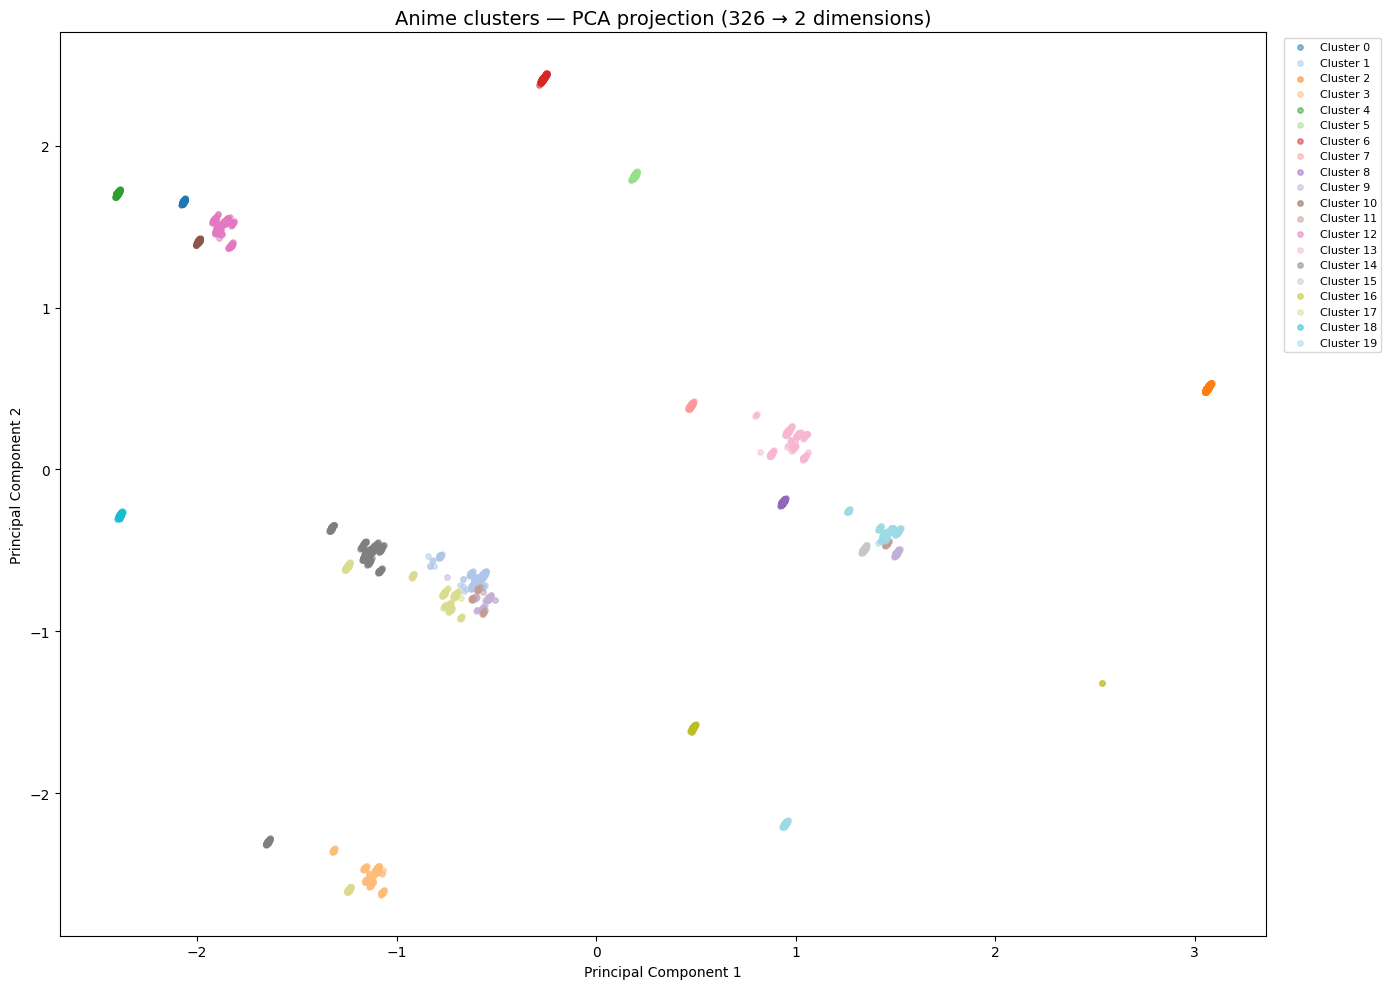

In [42]:
## Step 2 — Plot the clusters.
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(14, 10))

# Assign a distinct colour to each of the 20 clusters
colours = cm.tab20(np.linspace(0, 1, 20))

for cluster_id in range(20):
    mask = df_clean['Cluster'] == cluster_id
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=[colours[cluster_id]],
        label=f"Cluster {cluster_id}",
        alpha=0.5,
        s=15
    )

ax.set_title("Anime clusters — PCA projection (326 → 2 dimensions)", fontsize=14)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


- The isolated dots — the bright red cluster at the very top (~0, 2.4) and the large orange blob at the far right (~3, 0.4) are genre combinations that are genuinely unusual in the dataset. They sit far from everything else because few other anime share their feature profile
- The dense centre — the overlapping groups around (-1, -0.6) are clusters with similar genre combinations (Action/Comedy, Action/Drama, Action/Adventure etc.). They're nearby in the plot because they share many features, but K-Means still separated them into distinct groups
- The tight dots — each cluster is very compact, which reflects the discrete nature of one-hot genre encoding. Anime with identical genre tags sit at almost the same point in 326-dimensional space

The 39.7% variance explanation is why some clusters look close together — the remaining 60% of structure isn't shown in 2D. But the separation we can see is real.

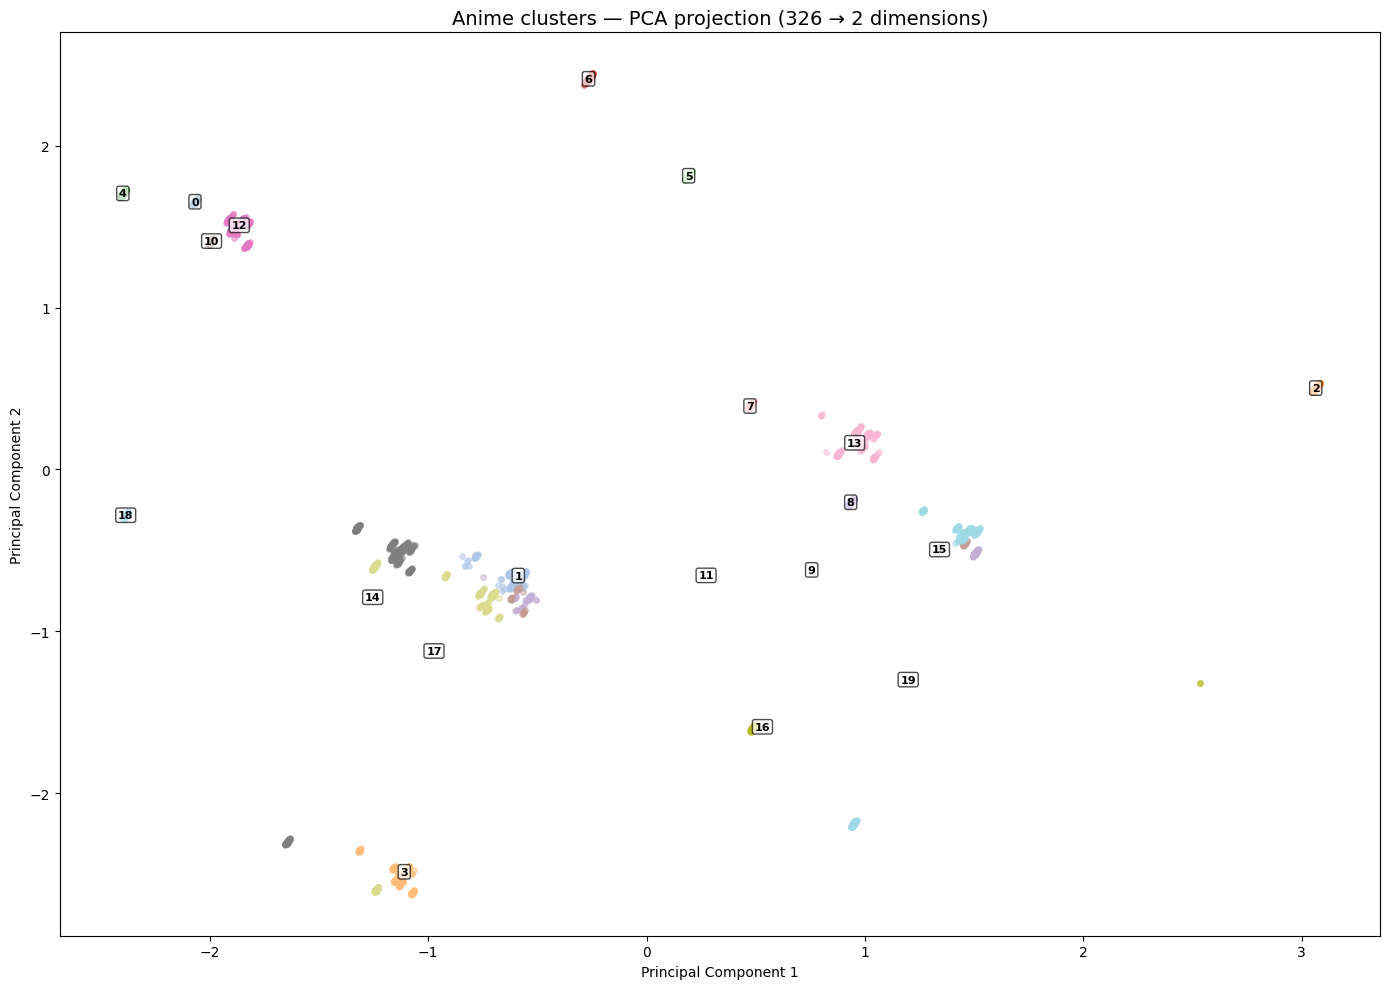

In [43]:
## Step 3 — Add cluster labels to make it readable.
fig, ax = plt.subplots(figsize=(14, 10))
colours = cm.tab20(np.linspace(0, 1, 20))

for cluster_id in range(20):
    mask = df_clean['Cluster'] == cluster_id
    ax.scatter(
        coords[mask, 0], coords[mask, 1],
        c=[colours[cluster_id]],
        alpha=0.5, s=15
    )
    # Label each cluster at its centre
    cx, cy = coords[mask, 0].mean(), coords[mask, 1].mean()
    ax.annotate(str(cluster_id), (cx, cy), fontsize=8, fontweight='bold',
                ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

ax.set_title("Anime clusters — PCA projection (326 → 2 dimensions)", fontsize=14)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

Upper left — comedy and light shows
Clusters 0, 10, 12 are grouped together (Romance/Comedy, Fantasy/Comedy, general Comedy). They're near each other because they share comedy genre tags.

Top centre — Cluster 6
Adventure/Comedy (Future Boy Conan, The Mysterious Cities of Gold) sits alone at the very top, isolated. It has a distinctive genre combination that doesn't sit neatly with anything else.

Far right — Cluster 2
This is the big Action/Adventure cluster (AoT, FMA Brotherhood, One Piece). It's completely isolated on the right side. That isolation is meaningful — it means when you query AoT, the model can only recommend from that tight isolated group. It's impossible for a romance or comedy show to sneak in.

Centre right — Clusters 8 and 15 are adjacent
Action/Drama (NGE, Code Geass) and Action/Fantasy (Demon Slayer) sit next to each other. Both are serious/dark action shows — the model placed them close but still distinct.

Bottom — Clusters 3 and 16
Short films and OVAs sit at the bottom, separate from everything. The model learned that short-form content is a distinct category.

In [44]:
recommend("Neon Genesis Evangelion")


,Title,Score,Similarity,Rating,Votes,Year,Genres
0,Legend of the Galactic Heroes,0.982,0.990,9.0,4201,1988,"Animation, Action, Drama"
1,Code Geass,0.980,0.991,8.7,75288,2006,"Animation, Action, Drama"
2,Tomorrow's Joe 2,0.979,0.988,8.9,684,1980,"Animation, Action, Drama"
3,Kingdom,0.977,0.991,8.5,2740,2012,"Animation, Action, Drama"
4,Parasyte: The Maxim,0.975,0.991,8.3,44346,2014,"Animation, Action, Drama"
5,The Rose of Versailles,0.975,0.990,8.4,2191,1979,"Animation, Action, Drama"
6,Initial D: Fourth Stage,0.974,0.992,8.2,1325,2004,"Animation, Action, Drama"
7,86,0.973,0.990,8.2,6503,2021,"Animation, Action, Drama"
8,Ghost in the Shell: S.A.C. 2nd GIG - Individua...,0.973,0.988,8.3,3237,2006,"Animation, Action, Drama"
9,Akira,0.972,0.991,8.0,197226,1988,"Animation, Action, Drama"


In [1]:
import pandas as pd

# Read only the first 5 rows — just to see the columns
for filename in ['UserAnimeList.csv', 'UserList.csv']:
    df = pd.read_csv(filename, nrows=5)
    print(f"=== {filename} ===")
    print(f"Columns: {df.columns.tolist()}")
    print(df.head(2))
    print()


=== UserAnimeList.csv ===
Columns: ['username', 'anime_id', 'my_watched_episodes', 'my_start_date', 'my_finish_date', 'my_score', 'my_status', 'my_rewatching', 'my_rewatching_ep', 'my_last_updated', 'my_tags']
   username  anime_id  my_watched_episodes my_start_date my_finish_date  \
0  karthiga        21                  586    0000-00-00     0000-00-00   
1  karthiga        59                   26    0000-00-00     0000-00-00   

   my_score  my_status  my_rewatching  my_rewatching_ep  my_last_updated  \
0         9          1            NaN                 0       1362307973   
1         7          2            NaN                 0       1362923691   

   my_tags  
0      NaN  
1      NaN  

=== UserList.csv ===
Columns: ['username', 'user_id', 'user_watching', 'user_completed', 'user_onhold', 'user_dropped', 'user_plantowatch', 'user_days_spent_watching', 'gender', 'location', 'birth_date', 'access_rank', 'join_date', 'last_online', 'stats_mean_score', 'stats_rewatched', 'stats_ep

In [2]:
import pandas as pd

chunks = []
for chunk in pd.read_csv('UserAnimeList.csv', chunksize=100_000,
                         usecols=['username', 'anime_id', 'my_score', 'my_status']):
    filtered = chunk[(chunk['my_status'] == 2) & (chunk['my_score'] > 0)]
    chunks.append(filtered)

ratings = pd.concat(chunks, ignore_index=True)
print(ratings.shape)
print(ratings.head(3))


(42398973, 4)
   username  anime_id  my_score  my_status
0  karthiga        59         7          2
1  karthiga        74         7          2
2  karthiga       120         7          2


In [3]:
print(f"Unique users:  {ratings['username'].nunique():,}")
print(f"Unique anime:  {ratings['anime_id'].nunique():,}")
print(f"Total ratings: {len(ratings):,}")

Unique users:  267,138
Unique anime:  13,713
Total ratings: 42,398,973


- 42M ratings ÷ 267K users = ~158 ratings per user on average — active users, not noise
- 42M ratings ÷ 13K anime = ~3,091 ratings per anime on average — plenty of signal per title

The matrix we'll build: 267,138 users × 13,713 anime, with 42M non-zero entries. That's only 1.15% filled — the rest are zeros (user hasn't rated that anime). This is called a sparse matrix and scipy has a special data structure for it that only stores the non-zero entries, so it stays memory efficient.

The plan:

1. Encode usernames and anime IDs as integers (sparse matrix needs integer indices)
2. Build the sparse matrix with scipy
3. Compute item-item cosine similarity — same technique as our content model, just applied to user rating patterns instead of genre/plot features
4. Bridge it to our existing recommender by matching MAL anime titles to our dataset
5. Blend CF similarity with content similarity for a hybrid result



In [4]:
import numpy as np
from scipy.sparse import csr_matrix

# Step 1: encode usernames and anime_ids as consecutive integers
user_enc = {u: i for i, u in enumerate(ratings['username'].unique())}
anime_enc = {a: i for i, a in enumerate(ratings['anime_id'].unique())}

row = ratings['username'].map(user_enc).values
col = ratings['anime_id'].map(anime_enc).values
data = ratings['my_score'].values.astype(np.float32)

# Step 2: build sparse matrix — shape (users, anime)
user_item = csr_matrix((data, (row, col)),
                       shape=(len(user_enc), len(anime_enc)))

print(f"Matrix shape: {user_item.shape}")
print(f"Non-zero entries: {user_item.nnz:,}")
print(f"Memory usage: {user_item.data.nbytes / 1e6:.1f} MB")


Matrix shape: (267139, 13713)
Non-zero entries: 42,398,973
Memory usage: 169.6 MB


Now compute the item-item similarity. This is the slow step — we're computing cosine similarity between 13,713 anime vectors, each 267K dimensions long. It'll take 1–2 minutes:

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

# Transpose: we want anime as rows, users as columns
# Each anime is now a vector of user scores
item_matrix = user_item.T  # shape: (13713, 267139)

# Compute anime-anime similarity from rating patterns
cf_similarity = cosine_similarity(item_matrix)

print(f"CF similarity matrix shape: {cf_similarity.shape}")
print(f"Memory: {cf_similarity.nbytes / 1e6:.1f} MB")

CF similarity matrix shape: (13713, 13713)
Memory: 752.2 MB


In [6]:
# Load title metadata so we can look up by name
anime_meta = pd.read_csv('AnimeList.csv', usecols=['anime_id', 'title', 'genre', 'score'])
id_to_title = anime_meta.set_index('anime_id')['title'].to_dict()
title_to_id = anime_meta.set_index('title')['anime_id'].to_dict()
idx_to_anime = {v: k for k, v in anime_enc.items()}  # reverse lookup: index → anime_id

def cf_recommend(title, n=10):
    if title not in title_to_id:
        print(f"'{title}' not found")
        return
    anime_id = title_to_id[title]
    if anime_id not in anime_enc:
        print(f"'{title}' has no ratings data")
        return

    idx = anime_enc[anime_id]
    scores = cf_similarity[idx]
    top_idx = scores.argsort()[::-1][1:n+1]

    results = []
    for i in top_idx:
        aid = idx_to_anime[i]
        results.append({
            'Title':         id_to_title.get(aid, f'id={aid}'),
            'CF Similarity': round(float(scores[i]), 3),
        })
    return pd.DataFrame(results)

# Test with two very different shows
print("=== Attack on Titan ===")
display(cf_recommend("Shingeki no Kyojin"))

print("\n=== Spirited Away ===")
display(cf_recommend("Sen to Chihiro no Kamikakushi"))

=== Attack on Titan ===


,Title,CF Similarity
0,Sword Art Online,0.714
1,Tokyo Ghoul,0.695
2,One Punch Man,0.670
3,No Game No Life,0.653
4,Mirai Nikki (TV),0.642
5,Noragami,0.641
6,Death Note,0.635
7,Steins;Gate,0.628
8,Fullmetal Alchemist: Brotherhood,0.624
9,Angel Beats!,0.620



=== Spirited Away ===


,Title,CF Similarity
0,Howl no Ugoku Shiro,0.733
1,Mononoke Hime,0.688
2,Tonari no Totoro,0.646
3,Toki wo Kakeru Shoujo,0.575
4,Death Note,0.568
5,Majo no Takkyuubin,0.549
6,Tenkuu no Shiro Laputa,0.538
7,Byousoku 5 Centimeter,0.525
8,Shingeki no Kyojin,0.518
9,Hotaru no Haka,0.514


In [7]:
import json

# Save CF similarity matrix
np.save('cf_similarity.npy', cf_similarity)

# Save anime metadata with both titles
anime_meta_full = pd.read_csv('AnimeList.csv', usecols=[
    'anime_id', 'title', 'title_english', 'genre', 'score'
])
anime_meta_full.to_csv('cf_anime_meta.csv', index=False)

# Save the anime_id → matrix index mapping
with open('cf_anime_enc.json', 'w') as f:
    json.dump({str(k): v for k, v in anime_enc.items()}, f)

print("Saved: cf_similarity.npy, cf_anime_meta.csv, cf_anime_enc.json")

Saved: cf_similarity.npy, cf_anime_meta.csv, cf_anime_enc.json


In [9]:
print(anime.columns.tolist())

['anime_id', 'title', 'title_english', 'title_japanese', 'title_synonyms', 'image_url', 'type', 'source', 'episodes', 'status', 'airing', 'aired_string', 'aired', 'duration', 'rating', 'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites', 'background', 'premiered', 'broadcast', 'related', 'producer', 'licensor', 'studio', 'genre', 'opening_theme', 'ending_theme']


In [10]:
print(anime['background'].dropna().iloc[0])
print(anime['background'].dropna().iloc[1])

Inu x Boku SS was licensed by Sentai Filmworks for North America, while MVM Films licensed it for the United Kingdom. During April 2013, Hanabee Entertainment released the series on DVD and Blu-ray for Australia and New Zealand.
Princess Tutu aired in two parts. The first part included 13 25-minute-long episodes, while the second part consisted of 24 12-minute-long episodes with a 25-minute-long final episode for a total of 25 episodes.
